In [2]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from matplotlib.backends.backend_pdf import PdfPages

In [3]:
pict_path = glob.glob('./IRheating_whole_cell_cell02_before_FAST/IRheating_whole_cell_cell02_before_FAST_ch00.tif')
pict_path.sort()
before = glob.glob('./IRheating_whole_cell_cell02_before_FAST/IRheating_whole_cell_cell02_before_FAST_ch01.tif')
before.sort()
during = glob.glob('./IRheating_whole_cell_cell02_during_FAST/IRheating_whole_cell_cell02_during_FAST_ch01.tif')
during.sort()

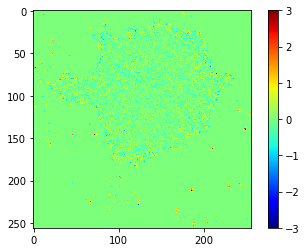

In [4]:
for i in range(len(before)):
    before_lifetime = np.array(Image.open(before[i]))
    during_lifetime = np.array(Image.open(during[i]))    

    before_lifetime = (before_lifetime)/1000                                
    during_lifetime = (during_lifetime)/1000                   
                         
    cell_shape = np.array(Image.open(pict_path[i]))
    cell_shape = np.where((cell_shape > 100), 1, 0)
    increase_lifetime_CP = (during_lifetime - before_lifetime)*cell_shape
    plt.imshow(increase_lifetime_CP, vmax = 3, vmin = -3, cmap = 'jet')
    plt.colorbar()
    
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 18
    plt.show()

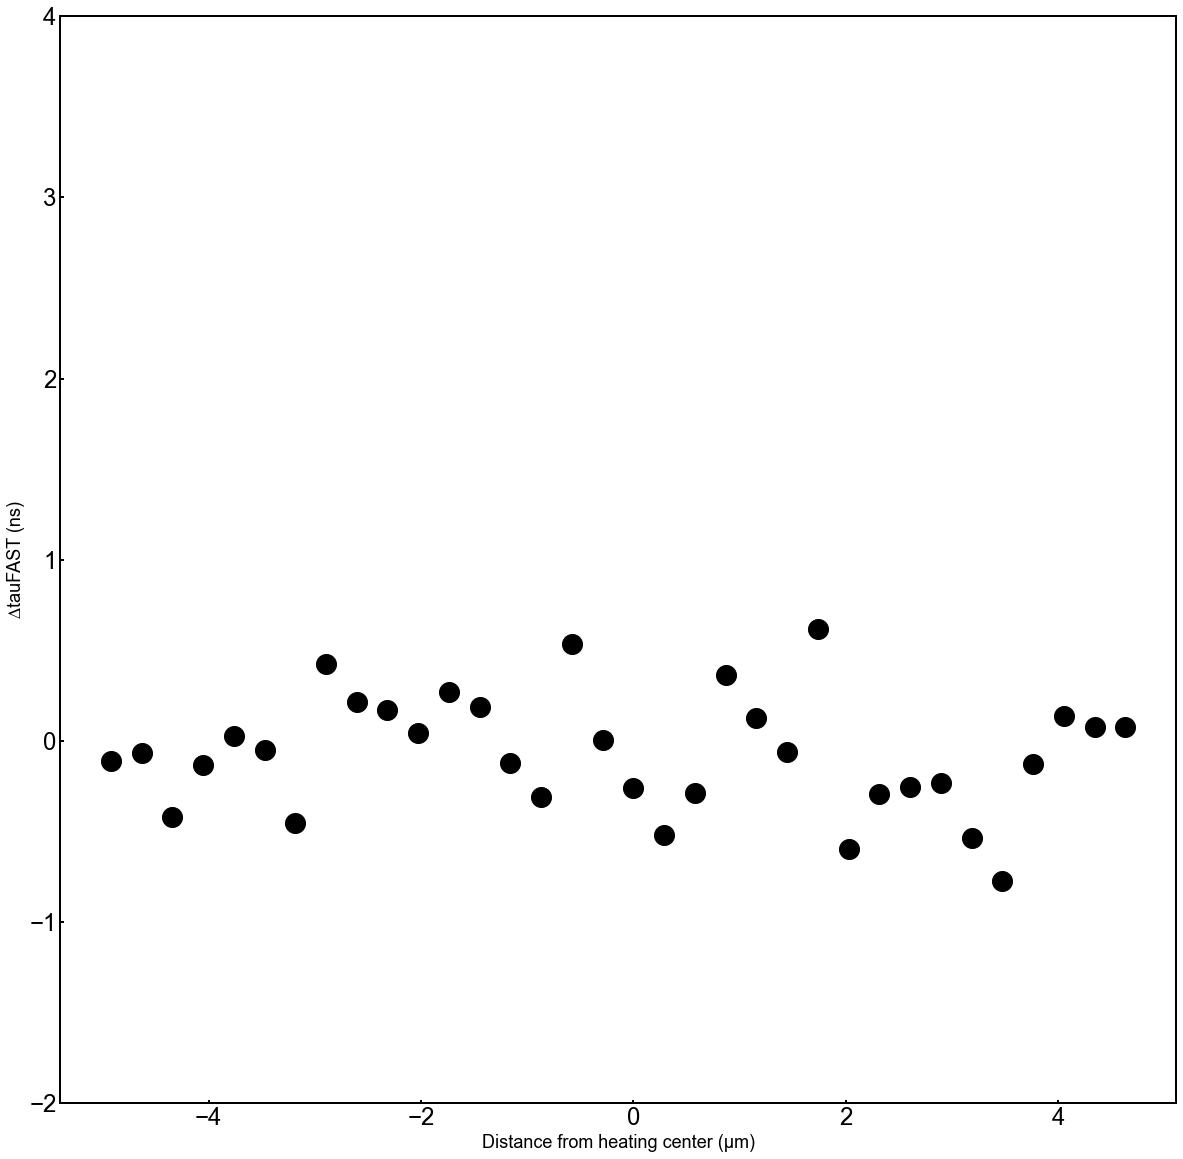

In [5]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
fig = plt.figure(figsize=(20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)


line = [(i-17)*74.1/256 for i in range(34)]
plt.plot(line, increase_lifetime_CP[98:132, 129], marker = 'o', linewidth = 0, color = 'black', markersize = 20)
plt.xlabel('Distance from heating center (µm)')
plt.ylabel('∆tauFAST (ns)')
plt.ylim(-2, 4)
plt.show()



#pdfのセーブ
pp = PdfPages('./Fig2b_CP.pdf')
pp.savefig(fig)
pp.close()

In [7]:
pd.DataFrame([line, increase_lifetime_CP[98:132, 129]]).to_csv('line_profile.csv')